In [1]:
%%capture
%pip install black[jupyter] blackcellmagic

In [2]:
import IPython
import black

# from google.colab import output


def format_cell(result):
    shell = IPython.get_ipython()
    raw_cell = shell.history_manager.input_hist_raw[-1]

    try:
        formatted = black.format_str(raw_cell, mode=black.Mode())
        if formatted.strip() != raw_cell.strip():
            # We update the cell content for the next time it is viewed/edited
            shell.set_next_input(formatted, replace=True)
    except Exception as e:
        # Skip formatting if there's a syntax error during the black process
        pass


# Register the hook to run after every cell execution
get_ipython().events.register("post_run_cell", format_cell)
print("Auto-formatter active: Cells will reformat automatically upon execution.")

Auto-formatter active: Cells will reformat automatically upon execution.


In [3]:
%%capture
%pip install uaibot

### Kinematic Control Strategy

The control system is based on the **Task Function Approach**. We define a task vector $r(q, t) \in \mathbb{R}^4$ that represents the error we want to minimize:

1.  **Position Error:** $s_e(q) - s_d(t)$, where $s_e$ is the end-effector position and $s_d(t)$ is the desired circular trajectory.
2.  **Orientation Error:** $1 - z_d^T z_e(q)$, where $z_e$ is the current Z-axis direction of the end-effector and $z_d$ is the target orientation.

#### Differential Kinematics
To find the joint velocities $\dot{q}$, we differentiate the task function:
$$\dot{r} = \frac{\partial r}{\partial q} \dot{q} + \frac{\partial r}{\partial t} = J_r \dot{q} + \frac{\partial r}{\partial t}$$

Where $J_r$ is the **Task Jacobian**. To ensure exponential stability ($r \to 0$), we impose the closed-loop behavior $\dot{r} = F(r)$, leading to the control law:
$$\dot{q} = J_r^{\dagger} \left( F(r) - \frac{\partial r}{\partial t} \right)$$

We use a **Damped Pseudoinverse** ($J_r^{\dagger}$) to handle potential kinematic singularities of the Franka Emika arm:
$$J_r^{\dagger} = J_r^T (J_r J_r^T + \lambda^2 I)^{-1}$$
where $\lambda$ is a damping factor.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import uaibot as ub

from typing import cast
from uaibot.simobjects import SimObject

robot = ub.Robot.create_franka_emika_3()

# Simulation parameters
dt = 0.01
t = 0
tmax = 12
n = np.shape(robot.q)[0]

# --- State Management ---
# Maintain external explicit kinematic state
q_current = np.copy(robot.q)
q_init = np.copy(robot.q)

# --- Trajectory Definition ---
# Strict YZ plane configuration
R = 0.2
x_c = 0.8  # Projected forward envelope
y_c = 0.0
z_c = 0.6
omega_d = np.pi / 2

s_d = lambda tt: np.matrix(
    [x_c, y_c + R * np.cos(omega_d * tt), z_c + R * np.sin(omega_d * tt)]
).reshape((3, 1))

s_d_dot = lambda tt: np.matrix(
    [0, -R * omega_d * np.sin(omega_d * tt), R * omega_d * np.cos(omega_d * tt)]
).reshape((3, 1))

z_d = np.matrix([1, 0, 0]).reshape((3, 1))

# Visual rendering compilation
pc = np.matrix(np.zeros((3, 0)))
for i in range(200):
    pc = np.block([pc, s_d(2 * np.pi * i / 199)])

target_pos_pc = ub.PointCloud(points=pc, size=0.03, color="purple")
ball_tr = ub.Ball(htm=np.asmatrix(np.identity(4)), radius=0.02, color="cyan")
sim = ub.Simulation(cast(list[SimObject], [robot, target_pos_pc, ball_tr]))


def fun_F(r):
    """
    Saturation function for error convergence.
    Analytically streamlined using np.sign for bounds evaluation.
    """
    A = 0.25
    w_tol = [0.01] * 4
    F = np.matrix(np.zeros((4, 1)))
    for i in range(4):
        if abs(r[i, 0]) < w_tol[i]:
            F[i, 0] = -A * (r[i, 0] / w_tol[i])
        else:
            F[i, 0] = -np.sign(r[i, 0]) * A
    return F


# Data storage
hist_r = np.matrix(np.zeros((4, 0)))
hist_u = np.matrix(np.zeros((n, 0)))
hist_t = []

# --- Control Loop ---
k0 = 1.0  # Null-space objective proportional gain

for _ in range(round(tmax / dt)):
    # 1. State Input Evaluation
    Jg, fk = robot.jac_geo(q_current)
    z_e = fk[0:3, 2]
    s_e = fk[0:3, 3]

    # 2. Task Jacobian & Mapping
    r = np.matrix(np.zeros((4, 1)))
    r[0:3] = s_e - s_d(t)
    r[3] = 1 - z_d.T * z_e

    Jr = np.matrix(np.zeros((4, n)))
    ff = np.vstack((-s_d_dot(t), np.zeros((1, 1))))

    Jr[0:3, :] = Jg[0:3, :]
    Jr[3, :] = z_d.T * ub.Utils.S(z_e) * Jg[3:6, :]

    # 3. Control Action with Null-Space Resolution
    J_pinv = ub.Utils.dp_inv(Jr, 0.001)

    # Primary minimum-norm velocity vector
    u_primary = J_pinv * (fun_F(r) - ff)

    # Secondary posture centering projection
    q_dot_0 = -k0 * (q_current - q_init)
    I_n = np.matrix(np.identity(n))
    N_Jr = I_n - J_pinv * Jr
    u_secondary = N_Jr * q_dot_0

    u = u_primary + u_secondary

    # Logging
    hist_r = np.block([hist_r, r])
    hist_u = np.block([hist_u, u])
    hist_t.append(t)

    # 4. Independent State Integration
    q_current = q_current + u * dt
    robot.add_ani_frame(time=t + dt, q=q_current)

    t += dt
    ball_tr.add_ani_frame(time=t, htm=ub.Utils.trn(s_d(t)))

sim.run()

ValueError: zero-size array to reduction operation minimum which has no identity

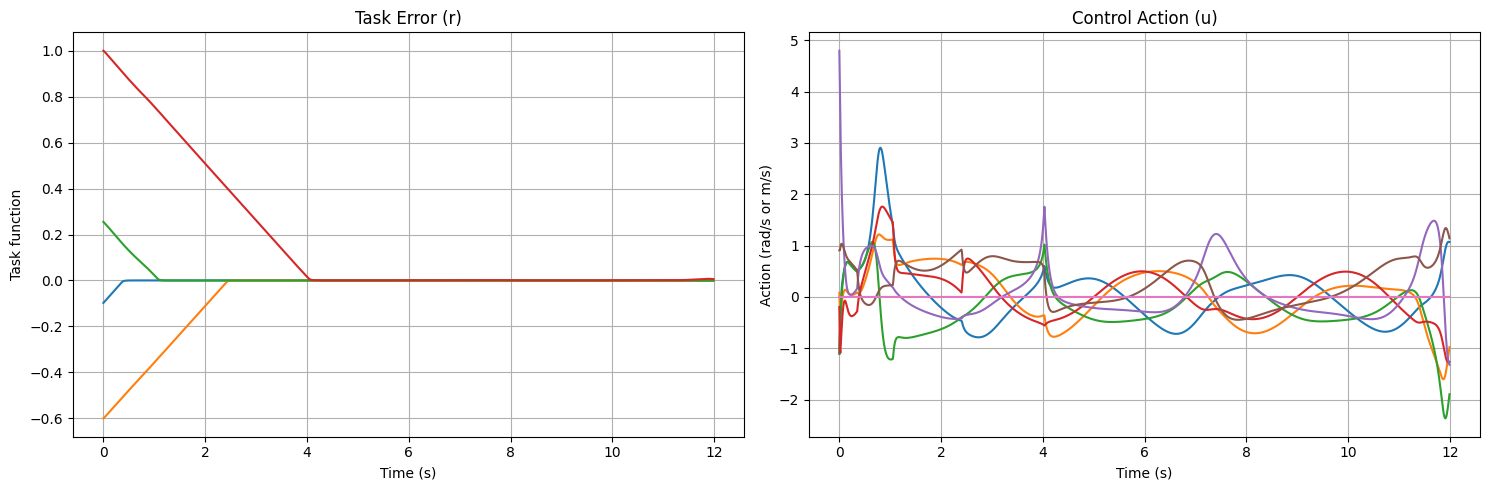

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Task Function (r)
ax1.plot(hist_t, hist_r.T)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Task function")
ax1.set_title("Task Error (r)")
ax1.grid(True)

# Plot Action (u)
ax2.plot(hist_t, hist_u.T)
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Action (rad/s or m/s)")
ax2.set_title("Control Action (u)")
ax2.grid(True)

plt.tight_layout()
plt.show()